Extract number of flows and their tos tags from the config.txt

In [23]:
config = {}
with open("ns-3-dev/config.txt", "r") as f:
    for line in f:
        line = line.strip()
        if not line: 
            continue
        traffic_type, values = line.split(":")
        n_flows, tag = values.split(",")
        config[traffic_type] = {'n_flows': int(n_flows), 'tag': tag}

print(config)
n_voip=config['VOIP']['n_flows']
n_ftp=config['FTP']['n_flows']
n_gaming=config['GAMING']['n_flows']
n_video=config['VIDEO']['n_flows']

{'VOIP': {'n_flows': 2, 'tag': '0xb8'}, 'FTP': {'n_flows': 1, 'tag': '0x0'}, 'GAMING': {'n_flows': 2, 'tag': '0x28'}, 'VIDEO': {'n_flows': 1, 'tag': '0x20'}}


In [24]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np


# Load the XML file
flowmon_path="ns-3-dev/multi-links-flow.xml"
tree = ET.parse(flowmon_path)  # Replace with your file path
root = tree.getroot()

# Prepare a list to collect parsed flow data
flow_data = []

# Iterate over all <Flow> elements inside <FlowStats>
#---------------nano seconds to second & bytes to Megabytes
for flow in root.find('FlowStats').findall('Flow'):
    flow_id = int(flow.attrib['flowId'])
    time_first_tx = float(flow.attrib['timeFirstTxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_first_rx = float(flow.attrib['timeFirstRxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_last_tx = float(flow.attrib['timeLastTxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_last_rx = float(flow.attrib['timeLastRxPacket'].replace('ns', '').replace('+', ''))*1E-9
    delay_sum = float(flow.attrib['delaySum'].replace('ns', '').replace('+', ''))*1E-9
    jitter_sum = float(flow.attrib['jitterSum'].replace('ns', '').replace('+', ''))*1E-9
    last_delay = float(flow.attrib['lastDelay'].replace('ns', '').replace('+', ''))*1E-9
    tx_bytes = int(flow.attrib['txBytes'])
    rx_bytes = int(flow.attrib['rxBytes'])
    tx_packets = int(flow.attrib['txPackets'])
    rx_packets = int(flow.attrib['rxPackets'])
    lost_packets = int(flow.attrib['lostPackets'])
    times_forwarded = int(flow.attrib['timesForwarded'])
    duration = time_last_rx - time_first_tx
    throughput_Mbps = (int(flow.attrib['rxBytes']) * 8) / (duration * 1e6)  # bits/sec → Mbps


    flow_data.append({
        'flow_id': flow_id,
        'time_first_tx_s': time_first_tx,
        'time_first_rx_s': time_first_rx,
        'time_last_tx_s': time_last_tx,
        'time_last_rx_s': time_last_rx,
        'delay_sum_s': delay_sum,
        'jitter_sum_s': jitter_sum,
        'last_delay_s': last_delay,
        'tx_bytes': tx_bytes,
        'rx_bytes': rx_bytes,
        'tx_packets': tx_packets,
        'rx_packets': rx_packets,
        'lost_packets': lost_packets,
        'times_forwarded': times_forwarded,
        'duration':duration,
        'throughput_Mbps':throughput_Mbps
    })

classifier_info = {}

for flow in root.find('Ipv4FlowClassifier').findall('Flow'):
    flow_id = int(flow.attrib['flowId'])

    # Find the <Dscp> child tag inside this flow
    dscp_elem = flow.find('Dscp')
    if dscp_elem is not None:
        # Convert hex string like "0x4" to int
        dscp_hex = dscp_elem.attrib.get('value')
        dscp_val = int(dscp_hex, 16)
        dscp_packets = dscp_elem.attrib.get('packets')
        tos_hex = hex(dscp_val << 2)
        

        
    else:
        dscp_value = None
        tos_val=None
        dscp_packets = None

    classifier_info[flow_id] = {
        'src': flow.attrib['sourceAddress'],
        'dst': flow.attrib['destinationAddress'],
        'src_port': int(flow.attrib.get('sourcePort', 0)),
        'dst_port': int(flow.attrib.get('destinationPort', 0)),
        'protocol': flow.attrib['protocol'],
        'DSCP': dscp_hex,
        'tos': tos_hex,
        'DSCP_packets': dscp_packets

    }

# Merge with previous stats if needed
for row in flow_data:
    fid = row['flow_id']
    if fid in classifier_info:
        row.update(classifier_info[fid])
df_flowmon = pd.DataFrame(flow_data)
df_flowmon['mean_delay']=  df_flowmon['delay_sum_s']/df_flowmon['rx_packets']
df_flowmon['mean-jitter']=df_flowmon['jitter_sum_s']/df_flowmon['rx_packets']

df_flowmon['flow_5tuple'] = (df_flowmon['src'].astype(str) + '-' +
                         df_flowmon['dst'].astype(str) + '-' +
                         df_flowmon['src_port'].astype(str) + '-' + 
                         df_flowmon['dst_port'].astype(str) + '-' +
                         df_flowmon['protocol'].astype(str)+'-'+
                         df_flowmon['DSCP'].astype(str))

# Base ports
base_ports = {
    'VOIP': 5060,
    'FTP': 21,
    'GAMING': 5000,
    'VIDEO': 16384
}
# Generate sets of ports per traffic type
voip_ports = set(base_ports['VOIP'] + i for i in range(n_voip))
ftp_ports = set(base_ports['FTP'] + i for i in range(n_ftp))
gaming_ports = set(base_ports['GAMING'] + i for i in range(n_gaming))
video_ports = set(base_ports['VIDEO'] + i for i in range(n_video))

# Define conditions
conditions = [
    df_flowmon['src_port'].isin(voip_ports) | df_flowmon['dst_port'].isin(voip_ports),
    df_flowmon['src_port'].isin(ftp_ports) | df_flowmon['dst_port'].isin(ftp_ports),
    df_flowmon['src_port'].isin(gaming_ports) | df_flowmon['dst_port'].isin(gaming_ports),
    df_flowmon['src_port'].isin(video_ports) | df_flowmon['dst_port'].isin(video_ports),
]

choices = ['VOIP', 'FTP', 'GAMING', 'VIDEO']

# Apply mapping
df_flowmon['traffic_type'] = np.select(conditions, choices, default='OTHER')


# Check result
print(df_flowmon[['src_port', 'dst_port', 'traffic_type']])

    src_port  dst_port traffic_type
0      49153        21          FTP
1      49154     16384        VIDEO
2      49155      5060         VOIP
3      49156      5061         VOIP
4         21     49153          FTP
5      16384     49154        VIDEO
6       5060     49155         VOIP
7       5061     49156         VOIP
8      49157      5000       GAMING
9      49158      5001       GAMING
10      5000     49157       GAMING
11      5001     49158       GAMING


Will output direct qnd ACK messages TCP flows (in both directions) and not the logical application flow

In [25]:
df_flowmon.head(2)

,flow_id,time_first_tx_s,time_first_rx_s,time_last_tx_s,time_last_rx_s,delay_sum_s,jitter_sum_s,last_delay_s,tx_bytes,rx_bytes,...,src_port,dst_port,protocol,DSCP,tos,DSCP_packets,mean_delay,mean-jitter,flow_5tuple,traffic_type
0,1,0.5,0.500964,100.790,101.076,3164.38,51.3857,0.286132,6323832,6149840,...,49153,21,6,0x0,0x0,10765,0.302262,0.004908,10.1.1.1-10.1.1.2-49153-21-6-0x0,FTP
1,2,0.5,0.501428,200.493,200.496,1575.65,36.6130,0.002932,2865901,2865901,...,49154,16384,6,0x8,0x20,18801,0.083807,0.001947,10.1.1.1-10.1.1.2-49154-16384-6-0x8,VIDEO


In [26]:
df_flowmon.columns

Index(['flow_id', 'time_first_tx_s', 'time_first_rx_s', 'time_last_tx_s',
       'time_last_rx_s', 'delay_sum_s', 'jitter_sum_s', 'last_delay_s',
       'tx_bytes', 'rx_bytes', 'tx_packets', 'rx_packets', 'lost_packets',
       'times_forwarded', 'duration', 'throughput_Mbps', 'src', 'dst',
       'src_port', 'dst_port', 'protocol', 'DSCP', 'tos', 'DSCP_packets',
       'mean_delay', 'mean-jitter', 'flow_5tuple', 'traffic_type'],
      dtype='object')

In [46]:
df_sorted = df_flowmon.sort_values(by="traffic_type")
df_sorted[['flow_id','DSCP','tos','flow_5tuple','rx_packets','traffic_type','throughput_Mbps','mean_delay', 'mean-jitter','lost_packets']]

,flow_id,DSCP,tos,flow_5tuple,rx_packets,traffic_type,throughput_Mbps,mean_delay,mean-jitter,lost_packets
0,1,0x0,0x0,10.1.1.1-10.1.1.2-49153-21-6-0x0,10469,FTP,0.489170,0.302262,4.908368e-03,296
4,5,0x0,0x0,10.1.1.2-10.1.1.1-21-49153-6-0x0,6538,FTP,0.030937,0.000993,7.341695e-07,0
8,9,0xa,0x28,10.1.1.1-10.1.1.2-49157-5000-6-0xa,3463,GAMING,0.026635,0.084761,5.068986e-03,0
9,10,0xa,0x28,10.1.1.1-10.1.1.2-49158-5001-6-0xa,3465,GAMING,0.026672,0.083977,5.084387e-03,0
10,11,0xa,0x28,10.1.1.2-10.1.1.1-5000-49157-6-0xa,1733,GAMING,0.003607,0.000932,4.616272e-07,0
11,12,0xa,0x28,10.1.1.2-10.1.1.1-5001-49158-6-0xa,1735,GAMING,0.003612,0.000932,1.844380e-08,0
1,2,0x8,0x20,10.1.1.1-10.1.1.2-49154-16384-6-0x8,18801,VIDEO,0.114638,0.083807,1.947396e-03,0
5,6,0x8,0x20,10.1.1.2-10.1.1.1-16384-49154-6-0x8,9402,VIDEO,0.019557,0.000932,3.403531e-09,0
2,3,0x2e,0xb8,10.1.1.1-10.1.1.2-49155-5060-6-0x2e,3994,VOIP,0.013986,0.090401,4.117451e-03,0
3,4,0x2e,0xb8,10.1.1.1-10.1.1.2-49156-5061-6-0x2e,3613,VOIP,0.012507,0.099798,4.438970e-03,0


inter_packet arrival (to adjust)

In [50]:
import pandas as pd
import numpy as np

# Load CSV
df_packet_rx = pd.read_csv('ns-3-dev/packet_arrival_times.txt', sep="\t", index_col=False)


# Group by full traffic type (including flow number)
traffic_groups = df_packet_rx.groupby("TrafficType")

interarrival = {}
times_dict = {}
size_dict = {}

for ttype, group in traffic_groups:
    # Ensure chronological order
    times = np.sort(group["Time(s)"].values)
    times_dict[ttype] = times

    sizes = np.sort(group["Size(Bytes)"].values)
    size_dict[ttype] = sizes

    # Compute interarrival times
    inter_times = np.diff(times)
    interarrival[ttype] = inter_times




In [54]:
import numpy as np

# Initialize the nested dictionary
interarrival = {}
times_dict = {}
size_dict = {}

# Group by TrafficType
traffic_groups = df_packet_rx.groupby("TrafficType")

for ttype, group in traffic_groups:
    # Initialize the sub-dictionary for each traffic type
    interarrival[ttype] = {}
    times_dict[ttype] = {}
    size_dict[ttype] = {}
    # Further group by FlowNumber within this traffic type
    flow_groups = group.groupby("numb_flow")
    
    for flow_num, flow_group in flow_groups:
        # Make sure timestamps are sorted
        times = np.sort(flow_group['Time(s)'].values)
        
        # Compute interarrival times
        inter_times = np.diff(times)
        
        # Store in the nested dictionary
        interarrival[ttype][flow_num] = inter_times
        times_dict[ttype][flow_num]=times
        size_dict[ttype][flow_num]=np.sort(flow_group['Size(Bytes)'].values)


In [56]:
size_dict

{'ftp': {1: array([    16,     72,     80, ...,  93264,  96480, 122944], shape=(7953,))},
 'gaming': {1: array([ 28,  48,  50, ..., 364, 424, 442], shape=(3461,)),
  2: array([ 45,  46,  47, ..., 403, 415, 430], shape=(3463,))},
 'video': {1: array([ 40,  40,  40, ..., 250, 250, 250], shape=(18799,))},
 'voip': {1: array([15, 15, 15, ..., 40, 40, 40], shape=(3992,)),
  2: array([15, 15, 15, ..., 40, 40, 40], shape=(3611,))}}

Vertical time pulses

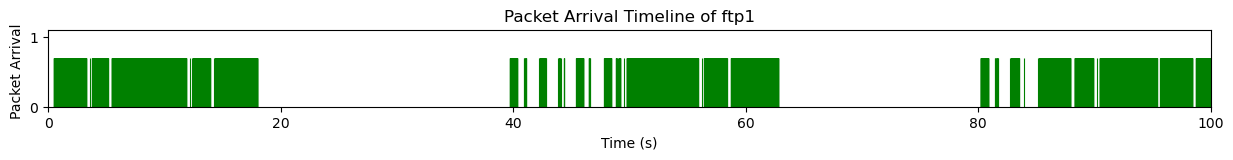

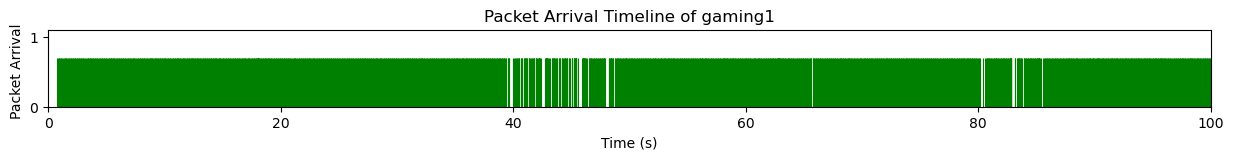

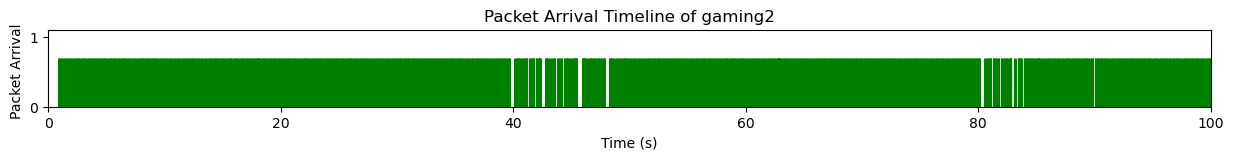

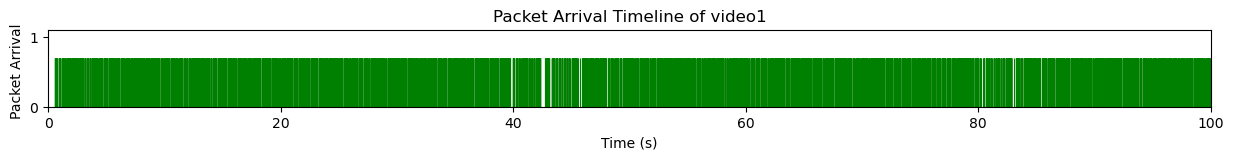

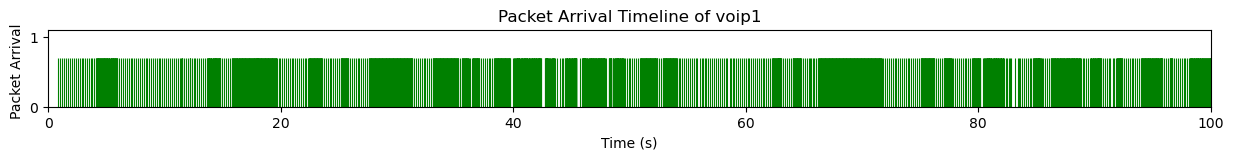

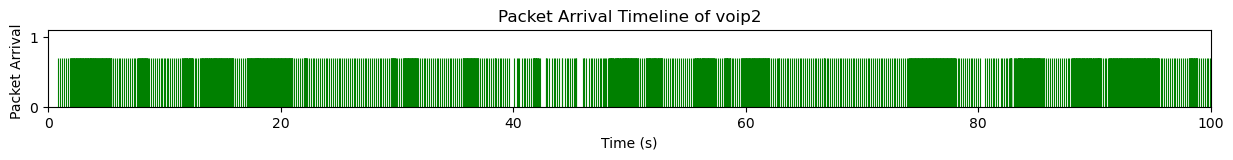

In [57]:
import matplotlib.pyplot as plt
for ttype, int_dict in times_dict.items():
    # Plot vertical lines at each timestamp
        for flux_numb, time_stamp in int_dict.items():
            plt.figure(figsize=(15, 1))
            plt.vlines(time_stamp, ymin=0, ymax=0.7, color="green", linewidth=0.8,alpha=1) 

            # Make it look like a signal timeline
            plt.xlim(0.0, 100)
            plt.ylim(0, 1.1)
            plt.xlabel("Time (s)")
            plt.ylabel("Packet Arrival ")
            plt.title(f"Packet Arrival Timeline of {ttype}{flux_numb}")
            plt.show()

In [31]:
"""
plt.figure(figsize=(15, 4))

for flow, ts in times_dict.items():
    sz = size_dict[flow]
    plt.figure(figsize=(15, 4))
    plt.plot(ts,sz)
    #plt.stem(ts, sz, label=flow, linefmt='C0-', markerfmt=' ', basefmt=' ')
    #plt.vlines(ts, ymin=0, ymax=500, color="green", linewidth=0.1)

    plt.xlabel('Time (s)')
    #plt.xlim(0.0, 18)
    #plt.ylim(0.0, 600)
    plt.ylabel('Packet size (bytes)')
    plt.title('Packet pulses per flow')
 
    plt.show()
"""

'\nplt.figure(figsize=(15, 4))\n\nfor flow, ts in times_dict.items():\n    sz = size_dict[flow]\n    plt.figure(figsize=(15, 4))\n    plt.plot(ts,sz)\n    #plt.stem(ts, sz, label=flow, linefmt=\'C0-\', markerfmt=\' \', basefmt=\' \')\n    #plt.vlines(ts, ymin=0, ymax=500, color="green", linewidth=0.1)\n\n    plt.xlabel(\'Time (s)\')\n    #plt.xlim(0.0, 18)\n    #plt.ylim(0.0, 600)\n    plt.ylabel(\'Packet size (bytes)\')\n    plt.title(\'Packet pulses per flow\')\n \n    plt.show()\n'